In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


In [1]:
import sklearn
print('sklearn.__version__', sklearn.__version__)

sklearn.__version__ 1.8.0


In [2]:
# ── 1. 用户-品类行为聚合表（21,696,561 行）──
user_cat = pd.read_csv(
    Path.cwd().parent /'user_category_agg.csv',
    dtype={
        'user_id':     'int32',
        'category_id': 'int32',
        'pv_count':    'int32',   # 用 int32 而非 int16，防止浏览量超过 32767 溢出
        'fav_count':   'int16',
        'cart_count':  'int16',
        'buy_count':   'int16'
    }
)

# ── 2. 用户聚类标签（只需 user_id + cluster，跳过 cluster_name 节省内存）──
user_cluster = pd.read_csv(
    Path.cwd().parent /'user_cluster_labels.csv',
    usecols=['user_id', 'cluster'],
    dtype={
        'user_id': 'int32',
        'cluster': 'int8'      # 只有 0-5，int8 足够（范围 -128~127）
    }
)

# ── 3. 高频商品购买聚合表 ──
item_buy = pd.read_csv(
    Path.cwd().parent /'item_buy_agg.csv',
    dtype={
        'user_id':     'int32',
        'item_id':     'int32',
        'category_id': 'int32',
        'buy_count':   'int16'
    }
)

# ── 验证 ──
print('user_cat shape    :', user_cat.shape)
print('user_cluster shape:', user_cluster.shape)
print('item_buy shape    :', item_buy.shape)
print()
print('── user_cat 前3行 ──')
print(user_cat.head(3))
print()
print('── user_cluster 前3行 ──')
print(user_cluster.head(3))
print()
print('── 聚类分布 ──')
print(user_cluster['cluster'].value_counts().sort_index())

user_cat shape    : (21696561, 6)
user_cluster shape: (983847, 2)
item_buy shape    : (1676494, 4)

── user_cat 前3行 ──
   user_id  category_id  pv_count  fav_count  cart_count  buy_count
0        1       149192         6          0           0          0
1        1       411153         3          0           0          0
2        1       982926         1          0           0          0

── user_cluster 前3行 ──
   user_id  cluster
0        1        0
1        2        4
2        3        3

── 聚类分布 ──
cluster
0    215893
1     64697
2    147436
3    114862
4     66492
5    374467
Name: count, dtype: int64


In [3]:
# merge 前先看 user_cat 有多少个唯一用户
n_users_cat = user_cat['user_id'].nunique()
print(f'user_cat 唯一用户数    : {n_users_cat:,}')
print(f'user_cluster 用户数    : {len(user_cluster):,}')
print(f'差值（无聚类标签的用户）: {n_users_cat - len(user_cluster):,}')
print()

# left join：保留所有 user_cat 记录，打上聚类标签
user_cat = user_cat.merge(user_cluster, on='user_id', how='left')

# 统计未匹配到聚类标签的记录数
missing_mask = user_cat['cluster'].isna()
missing_records = missing_mask.sum()
missing_users   = user_cat.loc[missing_mask, 'user_id'].nunique()
print(f'无聚类标签的记录数: {missing_records:,}')
print(f'无聚类标签的用户数: {missing_users:,}')
print()

# 策略：无标签用户单独标记为 cluster = -1（冷启动兜底组，后续用全局热门推荐）
user_cat['cluster'] = user_cat['cluster'].fillna(-1).astype('int8')

print('── merge 后聚类分布（-1 为无标签用户）──')
print(user_cat['cluster'].value_counts().sort_index())
print()
print('── merge 后 user_cat 前3行 ──')
print(user_cat.head(3))

user_cat 唯一用户数    : 983,847
user_cluster 用户数    : 983,847
差值（无聚类标签的用户）: 0

无聚类标签的记录数: 0
无聚类标签的用户数: 0

── merge 后聚类分布（-1 为无标签用户）──
cluster
0    2792681
1    2025338
2    4261113
3    2001165
4     723159
5    9893105
Name: count, dtype: int64

── merge 后 user_cat 前3行 ──
   user_id  category_id  pv_count  fav_count  cart_count  buy_count  cluster
0        1       149192         6          0           0          0        0
1        1       411153         3          0           0          0        0
2        1       982926         1          0           0          0        0


In [4]:
WEIGHTS = {'pv': 1, 'fav': 2, 'cart': 3, 'buy': 5}

user_cat['score'] = (
    user_cat['pv_count']   * WEIGHTS['pv']   +
    user_cat['fav_count']  * WEIGHTS['fav']  +
    user_cat['cart_count'] * WEIGHTS['cart'] +
    user_cat['buy_count']  * WEIGHTS['buy']
).astype('int32')

print('── 权重分数基本统计 ──')
print(user_cat['score'].describe().round(2))
print()
print(f'score = 0 的记录数（理论上不应存在）: {(user_cat["score"] == 0).sum():,}')

── 权重分数基本统计 ──
count    21696561.00
mean            4.88
std             8.79
min             1.00
25%             1.00
50%             2.00
75%             5.00
max           686.00
Name: score, dtype: float64

score = 0 的记录数（理论上不应存在）: 0


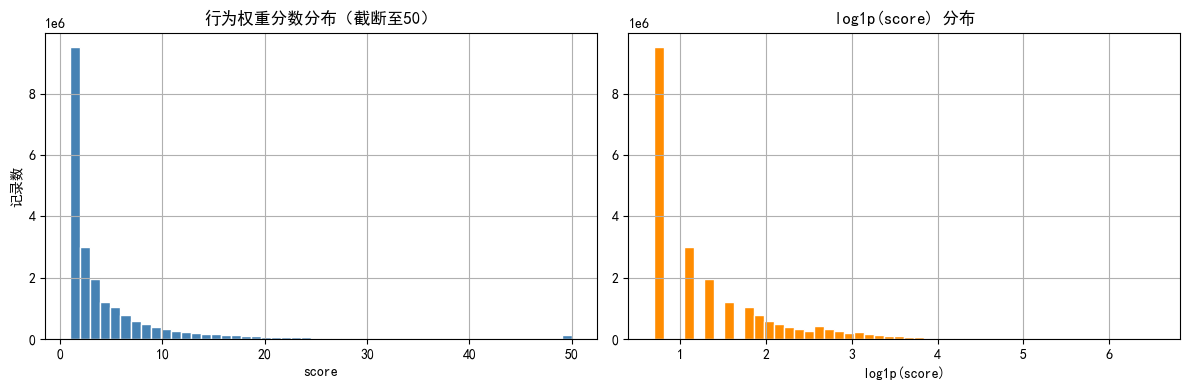

── score 分位数 ──
   50.0% 分位: 2
   75.0% 分位: 5
   90.0% 分位: 11
   95.0% 分位: 18
   99.0% 分位: 42
   99.9% 分位: 96


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

user_cat['score'].clip(upper=50).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('行为权重分数分布（截断至50）')
axes[0].set_xlabel('score')
axes[0].set_ylabel('记录数')

np.log1p(user_cat['score']).hist(
    bins=50, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('log1p(score) 分布')
axes[1].set_xlabel('log1p(score)')

plt.tight_layout()
plt.show()

# 看一下高分段的情况
print('── score 分位数 ──')
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
for q in quantiles:
    print(f'  {q*100:5.1f}% 分位: {user_cat["score"].quantile(q):.0f}')

In [6]:
MIN_USER_CAT = 2    # 用户至少与 N 个品类有过交互记录
MIN_CAT_USER = 5    # 品类至少被 N 个用户交互过

raw_users = user_cat['user_id'].nunique()
raw_cats  = user_cat['category_id'].nunique()
print(f'过滤前：{raw_users:,} 用户 × {raw_cats:,} 品类，{len(user_cat):,} 条记录')
print()

df = user_cat.copy()
for i in range(5):
    n_before = len(df)

    # 过滤低频用户
    user_counts = df.groupby('user_id')['category_id'].count()
    valid_users = user_counts[user_counts >= MIN_USER_CAT].index
    df = df[df['user_id'].isin(valid_users)]

    # 过滤低频品类
    cat_counts = df.groupby('category_id')['user_id'].count()
    valid_cats = cat_counts[cat_counts >= MIN_CAT_USER].index
    df = df[df['category_id'].isin(valid_cats)]

    n_after = len(df)
    print(f'第{i+1}轮：{n_before:,} → {n_after:,} 条  '
          f'（用户 {df["user_id"].nunique():,}，品类 {df["category_id"].nunique():,}）')
    if n_before == n_after:
        print('已收敛，停止迭代')
        break

user_cat_filtered = df.reset_index(drop=True)
print()

# 过滤后矩阵密度
n_users = user_cat_filtered['user_id'].nunique()
n_cats  = user_cat_filtered['category_id'].nunique()
density = len(user_cat_filtered) / (n_users * n_cats)
print(f'过滤后：{n_users:,} 用户 × {n_cats:,} 品类，{len(user_cat_filtered):,} 条记录')
print(f'矩阵密度：{density:.4%}')
print()

# 过滤前后各簇用户数对比
cluster_before = user_cat[['user_id','cluster']].drop_duplicates()['cluster'].value_counts().sort_index()
cluster_after  = user_cat_filtered[['user_id','cluster']].drop_duplicates()['cluster'].value_counts().sort_index()
compare = pd.DataFrame({'过滤前': cluster_before, '过滤后': cluster_after})
compare['保留率'] = (compare['过滤后'] / compare['过滤前']).map('{:.1%}'.format)
print('── 各簇用户保留情况 ──')
print(compare)

过滤前：983,847 用户 × 9,377 品类，21,696,561 条记录

第1轮：21,696,561 → 21,693,102 条  （用户 982,733，品类 8,244）
第2轮：21,693,102 → 21,693,100 条  （用户 982,731，品类 8,244）
第3轮：21,693,100 → 21,693,100 条  （用户 982,731，品类 8,244）
已收敛，停止迭代

过滤后：982,731 用户 × 8,244 品类，21,693,100 条记录
矩阵密度：0.2678%

── 各簇用户保留情况 ──
            过滤前     过滤后     保留率
cluster                        
0        215893  215100   99.6%
1         64697   64696  100.0%
2        147436  147415  100.0%
3        114862  114762   99.9%
4         66492   66306   99.7%
5        374467  374452  100.0%


In [7]:
# 读取 buy 行为原始记录（SQL 第3条导出的 buy_records.csv）
buy_raw = pd.read_csv(
    Path.cwd().parent /'buy_records.csv',
    usecols=['user_id', 'category_id', 'datetime'],
    dtype={'user_id': 'int32', 'category_id': 'int32'},
    parse_dates=['datetime']
)

print(f'buy 原始记录数：{len(buy_raw):,}')
print(f'涉及用户数    ：{buy_raw["user_id"].nunique():,}')
print(f'涉及品类数    ：{buy_raw["category_id"].nunique():,}')
print()

# 只保留过滤后存在的用户和品类
valid_users_set = set(user_cat_filtered['user_id'].unique())
valid_cats_set  = set(user_cat_filtered['category_id'].unique())

buy_raw = buy_raw[
    buy_raw['user_id'].isin(valid_users_set) &
    buy_raw['category_id'].isin(valid_cats_set)
].copy()

print(f'过滤后 buy 记录数：{len(buy_raw):,}')
print(f'过滤后用户数    ：{buy_raw["user_id"].nunique():,}')
print()

# 统计每个用户的购买次数，判断有多少用户只买过一次（无法切分）
buy_counts_per_user = buy_raw.groupby('user_id').size()
single_buy_users = (buy_counts_per_user == 1).sum()
multi_buy_users  = (buy_counts_per_user >= 2).sum()
print(f'只有1次购买记录的用户：{single_buy_users:,}（无法切分，全部进训练集）')
print(f'有2次及以上购买的用户：{multi_buy_users:,}（最后一次进测试集）')

buy 原始记录数：1,750,826
涉及用户数    ：626,650
涉及品类数    ：6,976

过滤后 buy 记录数：1,750,349
过滤后用户数    ：626,375

只有1次购买记录的用户：232,984（无法切分，全部进训练集）
有2次及以上购买的用户：393,391（最后一次进测试集）


In [8]:
# 有 2 次及以上购买的用户 → 最后一次买的品类作为测试 ground truth
buy_sorted = buy_raw.sort_values(['user_id', 'datetime'])

# 测试集：每个用户最后一次购买
test_gt = (
    buy_sorted.groupby('user_id')
              .last()
              .reset_index()[['user_id', 'category_id']]
              .rename(columns={'category_id': 'true_category'})
)

# 只保留有 2+ 次购买的用户进入测试集
valid_test_users = buy_counts_per_user[buy_counts_per_user >= 2].index
test_gt = test_gt[test_gt['user_id'].isin(valid_test_users)].reset_index(drop=True)

# 合并聚类标签到测试集（评估时按簇分析效果用）
test_gt = test_gt.merge(user_cluster, on='user_id', how='left')

print(f'测试集用户数：{len(test_gt):,}')
print()
print('── 测试集各簇分布 ──')
print(test_gt['cluster'].value_counts().sort_index())
print()
print('── 测试集前5行 ──')
print(test_gt.head())

测试集用户数：393,391

── 测试集各簇分布 ──
cluster
0       913
1     64696
2     64362
3     35950
4     53678
5    173792
Name: count, dtype: int64

── 测试集前5行 ──
   user_id  true_category  cluster
0        2        4159072        4
1        4        4801426        5
2       16        3898483        5
3       25        4159072        1
4       28        2774299        2


In [9]:
from scipy.sparse import csr_matrix
import numpy as np

# ── 从 buy_raw 中移除每个用户最后一次购买 ──
# buy_raw 在 Cell 7 已经加载好了，直接用
last_buy_index = (
    buy_raw.sort_values('datetime')
           .groupby('user_id')
           .tail(1)
           .index
)
buy_train = buy_raw.drop(index=last_buy_index)

print(f'原始 buy 记录        ：{len(buy_raw):,}')
print(f'移除最后一次后       ：{len(buy_train):,}')
print(f'移除记录数           ：{len(buy_raw) - len(buy_train):,}')
print()

# ── 重新统计训练集的 buy_count（每个 user-category 对）──
buy_train_agg = (
    buy_train.groupby(['user_id', 'category_id'])
             .size()
             .reset_index(name='buy_count_train')
             .astype({
                 'user_id': 'int32',
                 'category_id': 'int32',
                 'buy_count_train': 'int16'
             })
)

# ── 合并回 user_cat_filtered，替换 buy_count ──
user_cat_train = user_cat_filtered.merge(
    buy_train_agg, on=['user_id', 'category_id'], how='left'
)
user_cat_train['buy_count_train'] = (
    user_cat_train['buy_count_train'].fillna(0).astype('int16')
)

# ── 重新计算 score（用训练集 buy_count）──
WEIGHTS = {'pv': 1, 'fav': 2, 'cart': 3, 'buy': 5}
user_cat_train['score'] = (
    user_cat_train['pv_count']        * WEIGHTS['pv']   +
    user_cat_train['fav_count']       * WEIGHTS['fav']  +
    user_cat_train['cart_count']      * WEIGHTS['cart'] +
    user_cat_train['buy_count_train'] * WEIGHTS['buy']
).astype('int32')

print(f'score=0 的记录数（最后buy且无其他交互）：{(user_cat_train["score"]==0).sum():,}')
print()

# ── 构建稀疏矩阵（过滤 score=0 的记录）──
user_ids = user_cat_filtered['user_id'].unique()
cat_ids  = user_cat_filtered['category_id'].unique()

user2idx = {uid: i for i, uid in enumerate(user_ids)}
cat2idx  = {cid: i for i, cid in enumerate(cat_ids)}
idx2user = {i: uid for uid, i in user2idx.items()}
idx2cat  = {i: cid for cid, i in cat2idx.items()}

row  = user_cat_train['user_id'].map(user2idx).values
col  = user_cat_train['category_id'].map(cat2idx).values
data = np.log1p(user_cat_train['score'].values).astype(np.float32)

# 只保留 score > 0 的记录
mask = data > 0
user_item_matrix = csr_matrix(
    (data[mask], (row[mask], col[mask])),
    shape=(len(user_ids), len(cat_ids))
)

# ── 构建 buy_mask_matrix：只标记训练集中买过的品类 ──
# buy_train 是去掉最后一次后的购买记录，已在上面构建好
buy_mask_agg = (
    buy_train.groupby(['user_id', 'category_id'])
             .size()
             .reset_index(name='cnt')
)

mask_row  = buy_mask_agg['user_id'].map(user2idx).values
mask_col  = buy_mask_agg['category_id'].map(cat2idx).values
mask_data = np.ones(len(buy_mask_agg), dtype=np.float32)

# 过滤掉 user2idx/cat2idx 中不存在的记录
valid_mask = (
    buy_mask_agg['user_id'].isin(user2idx) &
    buy_mask_agg['category_id'].isin(cat2idx)
).values

buy_mask_matrix = csr_matrix(
    (mask_data[valid_mask], (mask_row[valid_mask], mask_col[valid_mask])),
    shape=(len(user_ids), len(cat_ids))
)

print(f'buy_mask_matrix 非零元素：{buy_mask_matrix.nnz:,}（训练集中买过的 user-category 对）')

print(f'矩阵维度    ：{user_item_matrix.shape[0]:,} 用户 × {user_item_matrix.shape[1]:,} 品类')
print(f'非零元素数  ：{user_item_matrix.nnz:,}')
print(f'矩阵密度    ：{user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4%}')



原始 buy 记录        ：1,750,349
移除最后一次后       ：1,123,974
移除记录数           ：626,375

score=0 的记录数（最后buy且无其他交互）：98,540

buy_mask_matrix 非零元素：978,907（训练集中买过的 user-category 对）
矩阵维度    ：982,731 用户 × 8,244 品类
非零元素数  ：21,594,560
矩阵密度    ：0.2665%


In [10]:
ITEM_BUY_THRESHOLD = 3  # 商品在全数据集累计被购买次数 ≥ N 才纳入 item 级事务

# ── Category 级事务集 ──
cat_transactions = (
    buy_raw.groupby('user_id')['category_id']
           .apply(lambda x: list(x.unique()))
           .reset_index(name='categories')
)
# 只保留购买了 2+ 个不同品类的用户（单品类无法产生关联规则）
cat_transactions = cat_transactions[
    cat_transactions['categories'].apply(len) >= 2
].reset_index(drop=True)

print('── Category 级事务集 ──')
print(f'事务数          ：{len(cat_transactions):,}')
print(f'平均每笔品类数  ：{cat_transactions["categories"].apply(len).mean():.2f}')
print(f'最大品类数      ：{cat_transactions["categories"].apply(len).max()}')
print()

# ── Item 级事务集（只取高频商品）──
item_freq       = item_buy.groupby('item_id')['buy_count'].sum()
high_freq_items = item_freq[item_freq >= ITEM_BUY_THRESHOLD].index
item_buy_hf     = item_buy[item_buy['item_id'].isin(high_freq_items)]

item_transactions = (
    item_buy_hf.groupby('user_id')['item_id']
               .apply(lambda x: list(x.unique()))
               .reset_index(name='items')
)
item_transactions = item_transactions[
    item_transactions['items'].apply(len) >= 2
].reset_index(drop=True)

print('── Item 级事务集 ──')
print(f'高频商品数      ：{len(high_freq_items):,}')
print(f'事务数          ：{len(item_transactions):,}')
print(f'平均每笔商品数  ：{item_transactions["items"].apply(len).mean():.2f}')

── Category 级事务集 ──
事务数          ：371,250
平均每笔品类数  ：3.46
最大品类数      ：66

── Item 级事务集 ──
高频商品数      ：139,409
事务数          ：276,261
平均每笔商品数  ：3.24


In [11]:
import pickle
import pandas as pd
from scipy.sparse import save_npz
from pathlib import Path

BASE = Path.cwd().parent  # 按你实际路径修改

# ── 稀疏矩阵单独存 .npz ──
save_npz(BASE / 'user_item_matrix.npz', user_item_matrix)
save_npz(BASE / 'buy_mask_matrix.npz', buy_mask_matrix)

# ── 索引映射 + 测试集 + 事务集存小 pkl ──
small_artifacts = {
    'user2idx': user2idx, 'idx2user': idx2user,
    'cat2idx':  cat2idx,  'idx2cat':  idx2cat,
    'test_gt':  test_gt,
    'user_cluster': user_cluster,
    'cat_transactions':  cat_transactions,
    'item_transactions': item_transactions,
    'high_freq_items':   high_freq_items,
}
with open(BASE / 'artifacts_small.pkl', 'wb') as f:
    pickle.dump(small_artifacts, f)

# ── user_cat_filtered 单独存 CSV（体积大，不放进 pkl）──
user_cat_filtered.to_csv(BASE / 'user_cat_filtered.csv', index=False)

print('buy_mask_matrix.npz 已保存')
print('✅ Step 1 保存完成')
print(f'  user_item_matrix.npz  → 稀疏矩阵')
print(f'  artifacts_small.pkl   → 映射字典 + 测试集 + 事务集')
print(f'  user_cat_filtered.csv → 过滤后主数据')
print('── 最终数据规模汇总 ──')
print(f'  训练矩阵     ：{user_item_matrix.shape[0]:,} 用户 × {user_item_matrix.shape[1]:,} 品类')
print(f'  矩阵密度     ：{user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4%}')
print(f'  测试集用户   ：{len(test_gt):,}')
print(f'  Category事务 ：{len(cat_transactions):,} 条')
print(f'  Item事务     ：{len(item_transactions):,} 条（高频商品 {len(high_freq_items):,} 个）')

buy_mask_matrix.npz 已保存
buy_mask_matrix.npz 已保存
✅ Step 1 保存完成
  user_item_matrix.npz  → 稀疏矩阵
  artifacts_small.pkl   → 映射字典 + 测试集 + 事务集
  user_cat_filtered.csv → 过滤后主数据
── 最终数据规模汇总 ──
  训练矩阵     ：982,731 用户 × 8,244 品类
  矩阵密度     ：0.2665%
  测试集用户   ：393,391
  Category事务 ：371,250 条
  Item事务     ：276,261 条（高频商品 139,409 个）
